In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
base_path = "/content/drive/MyDrive/EAS_508/"

In [ ]:
import os
os.listdir(base_path)

['airports.csv',
 'flights.csv',
 'weather_description.csv',
 'pressure.csv',
 'humidity.csv',
 'temperature.csv',
 'wind_speed.csv',
 'feature_importance.csv',
 'final_project_dataset.csv']

In [ ]:
flights = pd.read_csv(base_path + "flights.csv")

print("Original dataset shape:", flights.shape)
flights.head()

/tmp/ipykernel_10082/4059823255.py:1: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  flights = pd.read_csv(base_path + "flights.csv")


Original dataset shape: (5819079, 31)


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
flights_sample = flights.sample(n=150000, random_state=42).copy()

print("Sampled dataset shape:", flights_sample.shape)

Sampled dataset shape: (150000, 31)


In [ ]:
missing_values = flights_sample.isnull().sum().sort_values(ascending=False)
missing_values.head(20)

,0
CANCELLATION_REASON,147693
LATE_AIRCRAFT_DELAY,122594
WEATHER_DELAY,122594
AIRLINE_DELAY,122594
AIR_SYSTEM_DELAY,122594
SECURITY_DELAY,122594
ELAPSED_TIME,2673
AIR_TIME,2673
ARRIVAL_DELAY,2673
WHEELS_ON,2373


In [ ]:
delay_reason_cols = [
    "AIR_SYSTEM_DELAY",
    "SECURITY_DELAY",
    "AIRLINE_DELAY",
    "LATE_AIRCRAFT_DELAY",
    "WEATHER_DELAY"
]

flights_sample[delay_reason_cols] = flights_sample[delay_reason_cols].fillna(0)

In [ ]:
flights_sample["CANCELLATION_REASON"] = flights_sample["CANCELLATION_REASON"].fillna("Not Cancelled")

In [ ]:
flights_sample = flights_sample.dropna(subset=["ARRIVAL_DELAY", "DEPARTURE_DELAY"])

print("Shape after dropping missing delay targets:", flights_sample.shape)

Shape after dropping missing delay targets: (147327, 31)


In [ ]:
time_cols = [
    "AIR_TIME",
    "ELAPSED_TIME",
    "WHEELS_ON",
    "ARRIVAL_TIME",
    "WHEELS_OFF",
    "DEPARTURE_TIME",
    "TAXI_IN",
    "TAXI_OUT"
]

flights_sample[time_cols] = flights_sample[time_cols].fillna(0)

In [ ]:
flights_sample["TAIL_NUMBER"] = flights_sample["TAIL_NUMBER"].fillna("UNKNOWN")

In [ ]:
flights_sample.isnull().sum().sum()

np.int64(0)

In [ ]:
flights_sample["DATE"] = pd.to_datetime(
    flights_sample[["YEAR", "MONTH", "DAY"]]
)

flights_sample["TOTAL_DELAY"] = (
    flights_sample["ARRIVAL_DELAY"] + flights_sample["DEPARTURE_DELAY"]
)

flights_sample["IS_WEEKEND"] = flights_sample["DAY_OF_WEEK"].apply(
    lambda x: 1 if x >= 6 else 0
)

In [ ]:
flights_sample = flights_sample[
    flights_sample["ARRIVAL_DELAY"].between(-60, 240)
]

print("Shape after outlier removal:", flights_sample.shape)

Shape after outlier removal: (146746, 34)


In [ ]:
df_flights = flights_sample.sample(n=80000, random_state=42).reset_index(drop=True)

print("Final cleaned flight dataset shape:", df_flights.shape)
df_flights.head()

Final cleaned flight dataset shape: (80000, 34)


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,DATE,TOTAL_DELAY,IS_WEEKEND
0,2015,5,19,2,B6,1038,N715JB,AUS,BOS,1835,...,0,Not Cancelled,0.0,0.0,0.0,0.0,0.0,2015-05-19,-17.0,0
1,2015,9,26,6,F9,1121,N924FR,CVG,LAS,705,...,0,Not Cancelled,0.0,0.0,0.0,0.0,0.0,2015-09-26,5.0,1
2,2015,4,16,4,EV,2548,N680AE,ACT,DFW,1333,...,0,Not Cancelled,0.0,0.0,0.0,0.0,0.0,2015-04-16,5.0,0
3,2015,9,3,4,DL,1895,N668DN,PHL,ATL,1255,...,0,Not Cancelled,0.0,0.0,0.0,0.0,0.0,2015-09-03,-51.0,0
4,2015,11,16,1,OO,4697,N418SW,FWA,ATL,1659,...,0,Not Cancelled,85.0,0.0,0.0,0.0,0.0,2015-11-16,83.0,0


In [ ]:
print("Dataset shape:", df_flights.shape)

Dataset shape: (80000, 34)


In [ ]:
df_flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 34 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   YEAR                 80000 non-null  int64         
 1   MONTH                80000 non-null  int64         
 2   DAY                  80000 non-null  int64         
 3   DAY_OF_WEEK          80000 non-null  int64         
 4   AIRLINE              80000 non-null  object        
 5   FLIGHT_NUMBER        80000 non-null  int64         
 6   TAIL_NUMBER          80000 non-null  object        
 7   ORIGIN_AIRPORT       80000 non-null  object        
 8   DESTINATION_AIRPORT  80000 non-null  object        
 9   SCHEDULED_DEPARTURE  80000 non-null  int64         
 10  DEPARTURE_TIME       80000 non-null  float64       
 11  DEPARTURE_DELAY      80000 non-null  float64       
 12  TAXI_OUT             80000 non-null  float64       
 13  WHEELS_OFF           80000 non-

In [ ]:
df_flights.describe()

,YEAR,MONTH,DAY,DAY_OF_WEEK,FLIGHT_NUMBER,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,...,DIVERTED,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,DATE,TOTAL_DELAY,IS_WEEKEND
count,80000.0,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,...,80000.0,80000.0,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000,80000.000000,80000.000000
mean,2015.0,6.539125,15.724500,3.909650,2161.329700,1326.565638,1331.686775,7.955637,16.022875,1353.895150,...,0.0,0.0,2.388187,0.014225,2.889487,3.935987,0.388675,2015-07-02 09:08:31.920000,10.984550,0.256675
min,2015.0,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000,-38.000000,1.000000,1.000000,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,2015-01-01 00:00:00,-92.000000,0.000000
25%,2015.0,4.000000,8.000000,2.000000,720.000000,915.000000,917.750000,-5.000000,11.000000,933.000000,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,2015-04-05 00:00:00,-17.000000,0.000000
50%,2015.0,7.000000,16.000000,4.000000,1680.000000,1324.000000,1328.000000,-2.000000,14.000000,1341.000000,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,2015-07-03 00:00:00,-7.000000,0.000000
75%,2015.0,9.000000,23.000000,6.000000,3207.000000,1730.000000,1737.000000,7.000000,19.000000,1751.000000,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,2015-09-29 00:00:00,13.000000,1.000000
max,2015.0,12.000000,31.000000,7.000000,7438.000000,2359.000000,2400.000000,269.000000,153.000000,2400.000000,...,0.0,0.0,240.000000,90.000000,239.000000,237.000000,217.000000,2015-12-31 00:00:00,508.000000,1.000000
std,0.0,3.394497,8.760242,1.985072,1756.002593,483.807176,495.679331,28.626337,8.830164,497.120558,...,0.0,0.0,11.492987,0.750103,14.384935,17.507956,5.374809,NaN,58.637082,0.436801


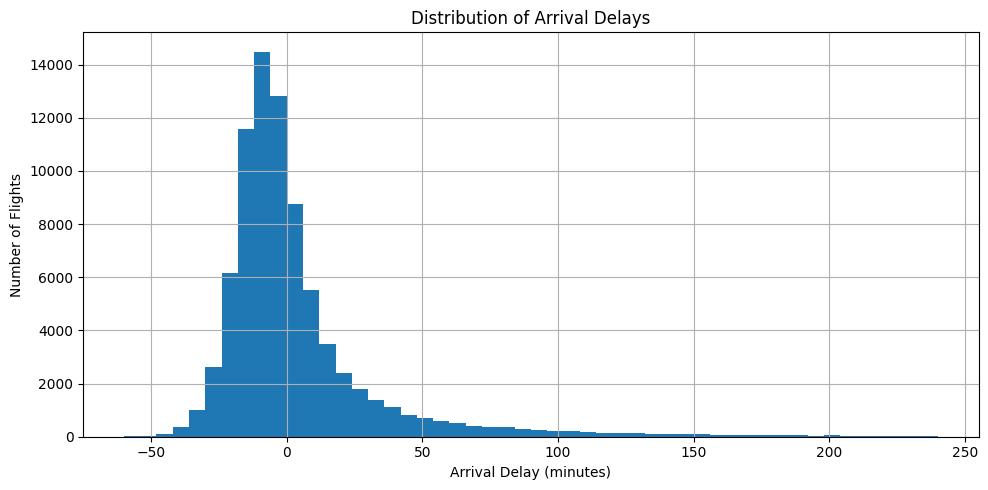

In [ ]:
plt.figure(figsize=(10,5))

df_flights["ARRIVAL_DELAY"].hist(bins=50)

plt.title("Distribution of Arrival Delays")
plt.xlabel("Arrival Delay (minutes)")
plt.ylabel("Number of Flights")

plt.tight_layout()
plt.show()

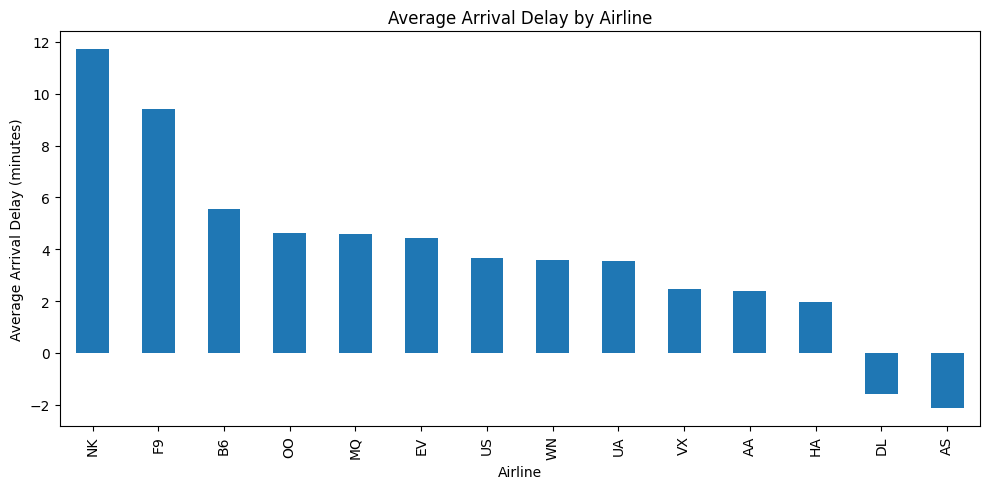

In [ ]:
airline_arrival_delay = (
    df_flights.groupby("AIRLINE")["ARRIVAL_DELAY"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

airline_arrival_delay.plot(kind="bar")

plt.title("Average Arrival Delay by Airline")
plt.xlabel("Airline")
plt.ylabel("Average Arrival Delay (minutes)")

plt.tight_layout()
plt.show()

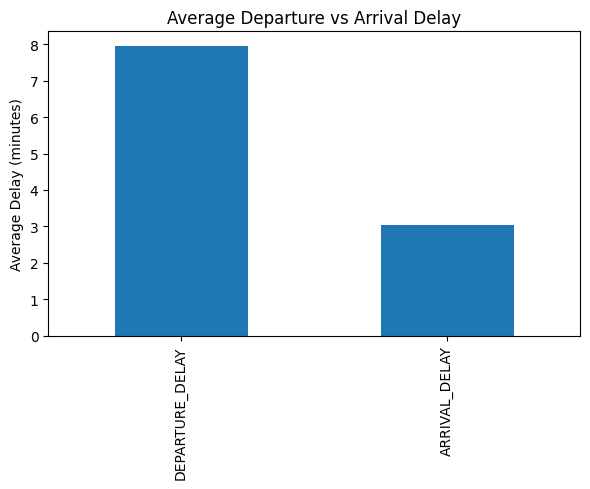

In [ ]:
delay_compare = df_flights[
    ["DEPARTURE_DELAY", "ARRIVAL_DELAY"]
].mean()

plt.figure(figsize=(6,5))

delay_compare.plot(kind="bar")

plt.title("Average Departure vs Arrival Delay")
plt.ylabel("Average Delay (minutes)")

plt.tight_layout()
plt.show()

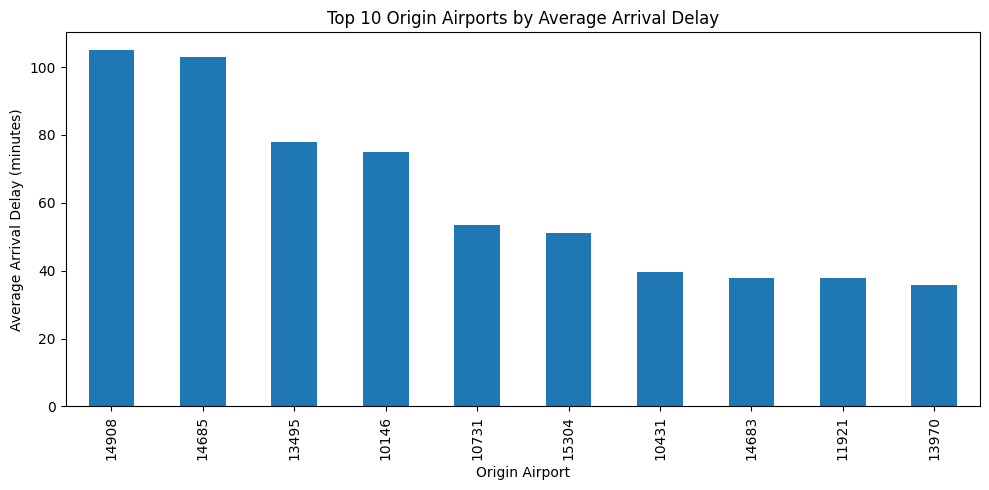

In [ ]:
airport_delay = (
    df_flights.groupby("ORIGIN_AIRPORT")["ARRIVAL_DELAY"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

airport_delay.plot(kind="bar")

plt.title("Top 10 Origin Airports by Average Arrival Delay")
plt.xlabel("Origin Airport")
plt.ylabel("Average Arrival Delay (minutes)")

plt.tight_layout()
plt.show()

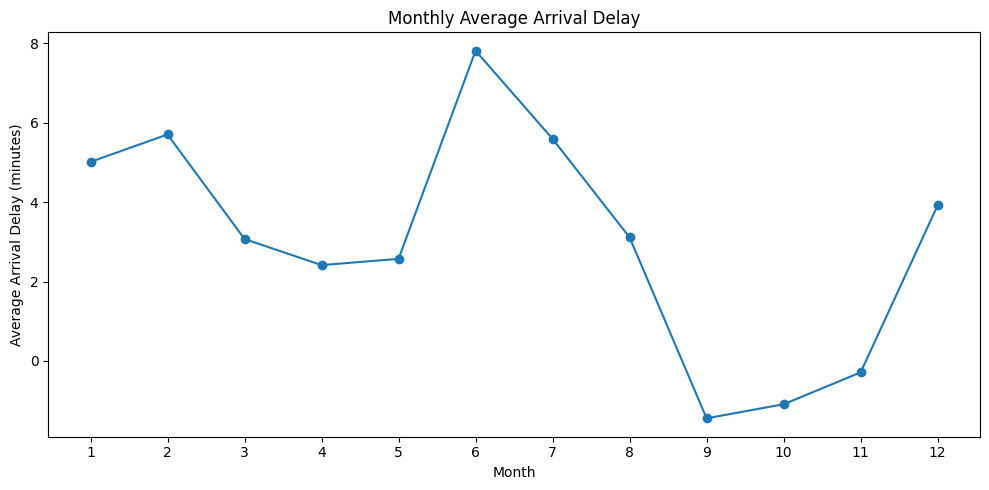

In [ ]:
monthly_delay = (
    df_flights.groupby("MONTH")["ARRIVAL_DELAY"]
    .mean()
)

plt.figure(figsize=(10,5))

monthly_delay.plot(marker="o")

plt.title("Monthly Average Arrival Delay")
plt.xlabel("Month")
plt.ylabel("Average Arrival Delay (minutes)")

plt.xticks(range(1,13))

plt.tight_layout()
plt.show()

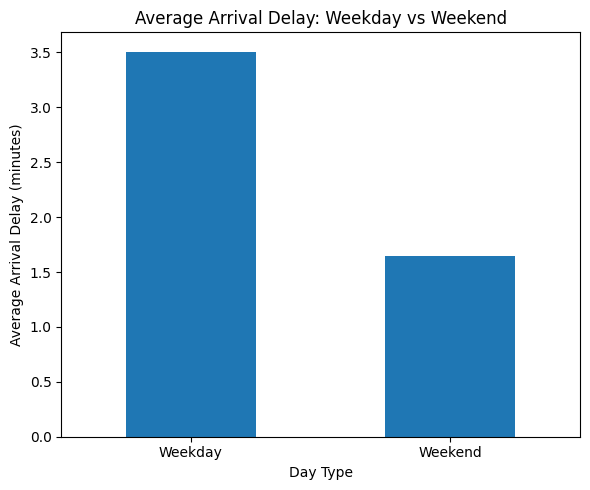

In [ ]:
weekend_delay = (
    df_flights.groupby("IS_WEEKEND")["ARRIVAL_DELAY"]
    .mean()
)

plt.figure(figsize=(6,5))

weekend_delay.plot(kind="bar")

plt.title("Average Arrival Delay: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Average Arrival Delay (minutes)")

plt.xticks([0,1], ["Weekday", "Weekend"], rotation=0)

plt.tight_layout()
plt.show()

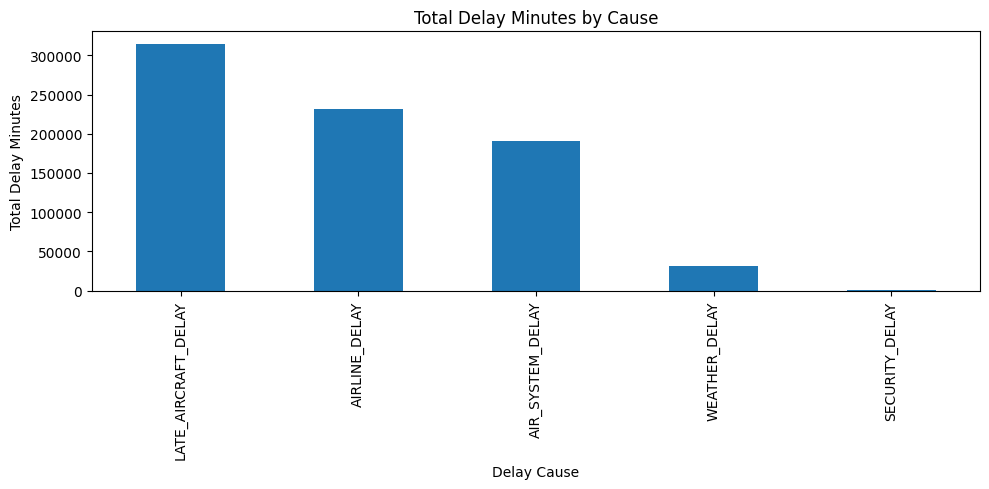

In [ ]:
delay_causes = df_flights[
    [
        "AIR_SYSTEM_DELAY",
        "SECURITY_DELAY",
        "AIRLINE_DELAY",
        "LATE_AIRCRAFT_DELAY",
        "WEATHER_DELAY"
    ]
].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))

delay_causes.plot(kind="bar")

plt.title("Total Delay Minutes by Cause")
plt.xlabel("Delay Cause")
plt.ylabel("Total Delay Minutes")

plt.tight_layout()
plt.show()

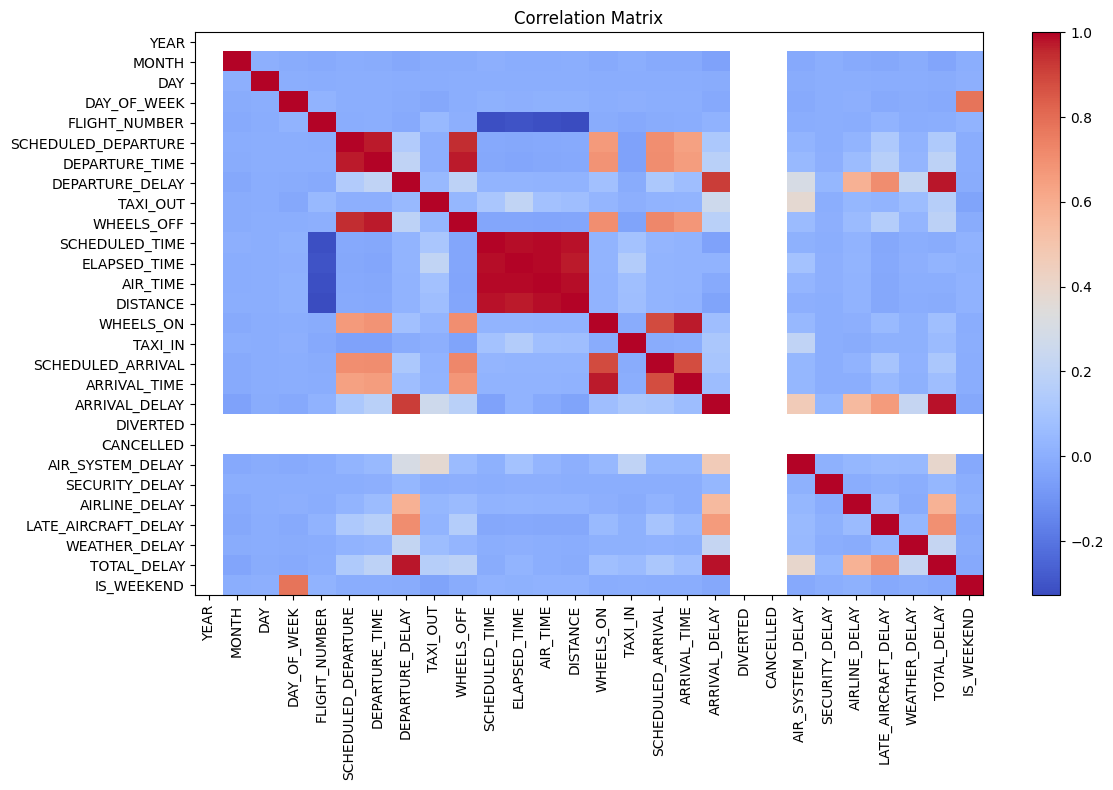

In [ ]:
numeric_cols = df_flights.select_dtypes(include=np.number)

correlation_matrix = numeric_cols.corr()

plt.figure(figsize=(12,8))

plt.imshow(correlation_matrix, cmap="coolwarm", aspect="auto")

plt.colorbar()

plt.title("Correlation Matrix")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.tight_layout()
plt.show()

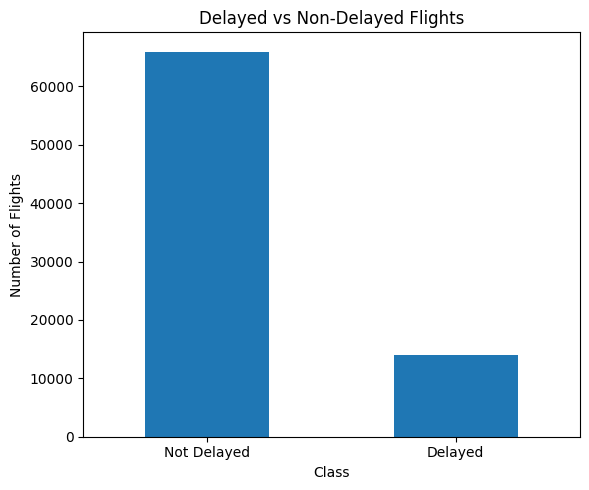

In [ ]:
df_flights["DELAYED"] = (
    df_flights["ARRIVAL_DELAY"] > 15
).astype(int)

delay_counts = df_flights["DELAYED"].value_counts()

plt.figure(figsize=(6,5))

delay_counts.plot(kind="bar")

plt.title("Delayed vs Non-Delayed Flights")
plt.xlabel("Class")
plt.ylabel("Number of Flights")

plt.xticks([0,1], ["Not Delayed", "Delayed"], rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
temp = pd.read_csv(base_path + "temperature.csv")
humidity = pd.read_csv(base_path + "humidity.csv")
wind = pd.read_csv(base_path + "wind_speed.csv")
weather_desc = pd.read_csv(base_path + "weather_description.csv")

In [ ]:
print(temp.shape)
temp.head()

(45253, 37)


,datetime,Vancouver,Portland,San Francisco,Seattle,Los Angeles,San Diego,Las Vegas,Phoenix,Albuquerque,...,Philadelphia,New York,Montreal,Boston,Beersheba,Tel Aviv District,Eilat,Haifa,Nahariyya,Jerusalem
0,2012-10-01 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,309.100000,NaN,NaN,NaN
1,2012-10-01 13:00:00,284.630000,282.080000,289.480000,281.800000,291.870000,291.530000,293.410000,296.600000,285.120000,...,285.630000,288.220000,285.830000,287.170000,307.590000,305.470000,310.580000,304.4,304.4,303.5
2,2012-10-01 14:00:00,284.629041,282.083252,289.474993,281.797217,291.868186,291.533501,293.403141,296.608509,285.154558,...,285.663208,288.247676,285.834650,287.186092,307.590000,304.310000,310.495769,304.4,304.4,303.5
3,2012-10-01 15:00:00,284.626998,282.091866,289.460618,281.789833,291.862844,291.543355,293.392177,296.631487,285.233952,...,285.756824,288.326940,285.847790,287.231672,307.391513,304.281841,310.411538,304.4,304.4,303.5
4,2012-10-01 16:00:00,284.624955,282.100481,289.446243,281.782449,291.857503,291.553209,293.381213,296.654466,285.313345,...,285.850440,288.406203,285.860929,287.277251,307.145200,304.238015,310.327308,304.4,304.4,303.5


In [ ]:
print(temp.columns)

Index(['datetime', 'Vancouver', 'Portland', 'San Francisco', 'Seattle',
       'Los Angeles', 'San Diego', 'Las Vegas', 'Phoenix', 'Albuquerque',
       'Denver', 'San Antonio', 'Dallas', 'Houston', 'Kansas City',
       'Minneapolis', 'Saint Louis', 'Chicago', 'Nashville', 'Indianapolis',
       'Atlanta', 'Detroit', 'Jacksonville', 'Charlotte', 'Miami',
       'Pittsburgh', 'Toronto', 'Philadelphia', 'New York', 'Montreal',
       'Boston', 'Beersheba', 'Tel Aviv District', 'Eilat', 'Haifa',
       'Nahariyya', 'Jerusalem'],
      dtype='object')


In [ ]:
print(temp.columns)
print(humidity.columns)
print(wind.columns)
print(weather_desc.columns)

Index(['datetime', 'Vancouver', 'Portland', 'San Francisco', 'Seattle',
       'Los Angeles', 'San Diego', 'Las Vegas', 'Phoenix', 'Albuquerque',
       'Denver', 'San Antonio', 'Dallas', 'Houston', 'Kansas City',
       'Minneapolis', 'Saint Louis', 'Chicago', 'Nashville', 'Indianapolis',
       'Atlanta', 'Detroit', 'Jacksonville', 'Charlotte', 'Miami',
       'Pittsburgh', 'Toronto', 'Philadelphia', 'New York', 'Montreal',
       'Boston', 'Beersheba', 'Tel Aviv District', 'Eilat', 'Haifa',
       'Nahariyya', 'Jerusalem'],
      dtype='object')
Index(['datetime', 'Vancouver', 'Portland', 'San Francisco', 'Seattle',
       'Los Angeles', 'San Diego', 'Las Vegas', 'Phoenix', 'Albuquerque',
       'Denver', 'San Antonio', 'Dallas', 'Houston', 'Kansas City',
       'Minneapolis', 'Saint Louis', 'Chicago', 'Nashville', 'Indianapolis',
       'Atlanta', 'Detroit', 'Jacksonville', 'Charlotte', 'Miami',
       'Pittsburgh', 'Toronto', 'Philadelphia', 'New York', 'Montreal',
       'Boston'

In [ ]:
airports = pd.read_csv(base_path + "airports.csv")

airports.head()

,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.44040
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.68190
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04022,-106.60919
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.44906,-98.42183
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.53552,-84.19447


In [ ]:
airports.columns

Index(['IATA_CODE', 'AIRPORT', 'CITY', 'STATE', 'COUNTRY', 'LATITUDE',
       'LONGITUDE'],
      dtype='object')

In [ ]:
available_cities = list(temp.columns)
available_cities.remove("datetime")

print("Number of weather cities:", len(available_cities))
print(available_cities[:20])

Number of weather cities: 36
['Vancouver', 'Portland', 'San Francisco', 'Seattle', 'Los Angeles', 'San Diego', 'Las Vegas', 'Phoenix', 'Albuquerque', 'Denver', 'San Antonio', 'Dallas', 'Houston', 'Kansas City', 'Minneapolis', 'Saint Louis', 'Chicago', 'Nashville', 'Indianapolis', 'Atlanta']


In [ ]:
airport_city_lookup = airports[["IATA_CODE", "CITY"]].drop_duplicates()

df_flights_city = df_flights.merge(
    airport_city_lookup,
    left_on="ORIGIN_AIRPORT",
    right_on="IATA_CODE",
    how="left"
)

df_flights_city[["ORIGIN_AIRPORT", "CITY"]].head()

,ORIGIN_AIRPORT,CITY
0,AUS,Austin
1,CVG,Covington
2,ACT,Waco
3,PHL,Philadelphia
4,FWA,Fort Wayne


In [ ]:
weather_flights = df_flights_city[
    df_flights_city["CITY"].isin(available_cities)
].copy()

print("Weather flights shape:", weather_flights.shape)

Weather flights shape: (40980, 37)


In [ ]:
cities = weather_flights["CITY"].dropna().unique().tolist()

print("Number of cities used:", len(cities))
print(cities[:20])

Number of cities used: 26
['Philadelphia', 'Atlanta', 'Houston', 'San Francisco', 'Albuquerque', 'Detroit', 'Minneapolis', 'Kansas City', 'Chicago', 'Denver', 'Phoenix', 'Las Vegas', 'Los Angeles', 'New York', 'Miami', 'Boston', 'San Diego', 'Charlotte', 'Dallas', 'Indianapolis']


In [ ]:
combined_weather = []

for city in cities:
    city_weather = pd.DataFrame()

    city_weather["DATE_TIME"] = pd.to_datetime(temp["datetime"])
    city_weather["CITY"] = city
    city_weather["TEMP"] = temp[city]
    city_weather["HUMIDITY"] = humidity[city]
    city_weather["WIND_SPEED"] = wind[city]
    city_weather["WEATHER_DESCRIPTION"] = weather_desc[city]

    combined_weather.append(city_weather)

weather_df = pd.concat(combined_weather, ignore_index=True)

weather_df["DATE"] = pd.to_datetime(weather_df["DATE_TIME"].dt.date)

weather_df.head()

,DATE_TIME,CITY,TEMP,HUMIDITY,WIND_SPEED,WEATHER_DESCRIPTION,DATE
0,2012-10-01 12:00:00,Philadelphia,NaN,NaN,NaN,NaN,2012-10-01
1,2012-10-01 13:00:00,Philadelphia,285.630000,71.0,4.0,broken clouds,2012-10-01
2,2012-10-01 14:00:00,Philadelphia,285.663208,70.0,4.0,broken clouds,2012-10-01
3,2012-10-01 15:00:00,Philadelphia,285.756824,70.0,3.0,broken clouds,2012-10-01
4,2012-10-01 16:00:00,Philadelphia,285.850440,69.0,3.0,broken clouds,2012-10-01


In [ ]:
daily_weather = weather_df.groupby(["DATE", "CITY"]).agg({
    "TEMP": "mean",
    "HUMIDITY": "mean",
    "WIND_SPEED": "mean",
    "WEATHER_DESCRIPTION": lambda x: x.mode()[0] if not x.mode().empty else "Unknown"
}).reset_index()

daily_weather.head()

,DATE,CITY,TEMP,HUMIDITY,WIND_SPEED,WEATHER_DESCRIPTION
0,2012-10-01,Albuquerque,285.476208,48.909091,4.0,sky is clear
1,2012-10-01,Atlanta,294.093604,94.000000,3.0,overcast clouds
2,2012-10-01,Boston,287.371091,68.000000,3.0,few clouds
3,2012-10-01,Charlotte,288.651832,87.000000,4.0,overcast clouds
4,2012-10-01,Chicago,284.552669,68.909091,0.0,overcast clouds


In [ ]:
daily_weather = weather_df.groupby(["DATE", "CITY"]).agg({
    "TEMP": "mean",
    "HUMIDITY": "mean",
    "WIND_SPEED": "mean",
    "WEATHER_DESCRIPTION": lambda x: x.mode()[0] if not x.mode().empty else "Unknown"
}).reset_index()

weather_merged = weather_flights.merge(
    daily_weather,
    on=["DATE", "CITY"],
    how="left"
)

In [ ]:
print(weather_merged.shape)

weather_merged.head()

(40980, 41)


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,DATE,TOTAL_DELAY,IS_WEEKEND,DELAYED,IATA_CODE,CITY,TEMP,HUMIDITY,WIND_SPEED,WEATHER_DESCRIPTION
0,2015,9,3,4,DL,1895,N668DN,PHL,ATL,1255,...,2015-09-03,-51.0,0,0,PHL,Philadelphia,299.045000,67.625000,1.958333,mist
1,2015,11,21,6,WN,2258,N776WN,ATL,MDW,1730,...,2015-11-21,125.0,1,1,ATL,Atlanta,283.701900,61.875000,2.291667,sky is clear
2,2015,8,17,1,EV,4703,N17196,IAH,BRO,2110,...,2015-08-17,21.0,0,1,IAH,Houston,299.882814,74.791667,2.166667,mist
3,2015,6,20,6,UA,1474,N28457,SFO,DEN,1308,...,2015-06-20,166.0,1,1,SFO,San Francisco,288.263190,82.791667,1.625000,few clouds
4,2015,6,12,5,WN,508,N607SW,ABQ,PHX,1350,...,2015-06-12,9.0,0,0,ABQ,Albuquerque,294.016371,40.208333,2.000000,sky is clear


In [ ]:
weather_merged.shape

(40980, 41)

In [ ]:
weather_merged[["DATE", "ORIGIN_AIRPORT", "CITY", "TEMP", "HUMIDITY", "WIND_SPEED", "WEATHER_DESCRIPTION"]].head(10)

,DATE,ORIGIN_AIRPORT,CITY,TEMP,HUMIDITY,WIND_SPEED,WEATHER_DESCRIPTION
0,2015-09-03,PHL,Philadelphia,299.045000,67.625000,1.958333,mist
1,2015-11-21,ATL,Atlanta,283.701900,61.875000,2.291667,sky is clear
2,2015-08-17,IAH,Houston,299.882814,74.791667,2.166667,mist
3,2015-06-20,SFO,San Francisco,288.263190,82.791667,1.625000,few clouds
4,2015-06-12,ABQ,Albuquerque,294.016371,40.208333,2.000000,sky is clear
5,2015-09-21,DTW,Detroit,289.045957,63.791667,2.250000,sky is clear
6,2015-07-06,MSP,Minneapolis,295.320833,78.416667,4.750000,mist
7,2015-08-27,MCI,Kansas City,293.728750,75.125000,3.000000,sky is clear
8,2015-03-30,ATL,Atlanta,285.383667,63.541667,3.500000,moderate rain
9,2015-06-21,MSP,Minneapolis,294.806503,81.416667,2.000000,sky is clear


In [ ]:
weather_merged.isnull().sum().sort_values(ascending=False).head(20)

,0
YEAR,0
MONTH,0
DAY,0
DAY_OF_WEEK,0
AIRLINE,0
FLIGHT_NUMBER,0
TAIL_NUMBER,0
ORIGIN_AIRPORT,0
DESTINATION_AIRPORT,0
SCHEDULED_DEPARTURE,0


In [ ]:
weather_match_rate = weather_merged["TEMP"].notnull().mean() * 100
print("Weather match rate:", weather_match_rate, "%")

Weather match rate: 100.0 %


In [ ]:
weather_merged["CITY"].value_counts()

,count
CITY,
Chicago,4903
Atlanta,4823
Houston,2735
Los Angeles,2704
Denver,2686
New York,2521
San Francisco,2005
Phoenix,1955
Las Vegas,1907


In [ ]:
weather_merged["ORIGIN_AIRPORT"].value_counts()

,count
ORIGIN_AIRPORT,
ATL,4823
ORD,3772
LAX,2704
DEN,2686
IAH,2046
SFO,2005
PHX,1955
LAS,1907
MSP,1543


In [ ]:
for col in ["TEMP", "HUMIDITY", "WIND_SPEED"]:
    weather_merged[col] = weather_merged[col].fillna(weather_merged[col].median())

weather_merged["WEATHER_DESCRIPTION"] = weather_merged["WEATHER_DESCRIPTION"].fillna("Unknown")

In [ ]:
weather_merged.isnull().sum().sum()

np.int64(0)

In [ ]:
weather_merged["DELAYED"] = (
    weather_merged["ARRIVAL_DELAY"] > 15
).astype(int)

weather_merged["DELAYED"].value_counts()

,count
DELAYED,
0,33163
1,7817


In [ ]:
basic_features = [

    "MONTH",

    "DAY",

    "DAY_OF_WEEK",

    "AIRLINE",

    "ORIGIN_AIRPORT",

    "DESTINATION_AIRPORT",

    "SCHEDULED_DEPARTURE",

    "DISTANCE",

    "IS_WEEKEND"
]

In [ ]:
X_basic = weather_merged[basic_features]

y_basic = weather_merged["DELAYED"]

In [ ]:
X_basic = pd.get_dummies(
    X_basic,
    drop_first=True
)

In [ ]:
from sklearn.model_selection import train_test_split

Xb_train, Xb_test, yb_train, yb_test = train_test_split(

    X_basic,

    y_basic,

    test_size=0.2,

    random_state=42,

    stratify=y_basic
)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=3000))
])

log_model.fit(Xb_train, yb_train)

log_pred = log_model.predict(Xb_test)

print("Logistic Regression Accuracy:", accuracy_score(yb_test, log_pred))
print(confusion_matrix(yb_test, log_pred))
print(classification_report(yb_test, log_pred))

Logistic Regression Accuracy: 0.8085651537335286
[[6620   13]
 [1556    7]]
              precision    recall  f1-score   support

           0       0.81      1.00      0.89      6633
           1       0.35      0.00      0.01      1563

    accuracy                           0.81      8196
   macro avg       0.58      0.50      0.45      8196
weighted avg       0.72      0.81      0.73      8196



In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(

    n_estimators=100,

    random_state=42,

    n_jobs=-1
)

rf_model.fit(
    Xb_train,
    yb_train
)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [ ]:
rf_pred = rf_model.predict(
    Xb_test
)

In [ ]:
print(
    "Random Forest Accuracy:",
    accuracy_score(yb_test, rf_pred)
)

print(confusion_matrix(
    yb_test,
    rf_pred
))

print(classification_report(
    yb_test,
    rf_pred
))

Random Forest Accuracy: 0.8052708638360175
[[6534   99]
 [1497   66]]
              precision    recall  f1-score   support

           0       0.81      0.99      0.89      6633
           1       0.40      0.04      0.08      1563

    accuracy                           0.81      8196
   macro avg       0.61      0.51      0.48      8196
weighted avg       0.73      0.81      0.74      8196



In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
dt_basic_model = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)

dt_basic_model.fit(Xb_train, yb_train)

dt_basic_pred = dt_basic_model.predict(Xb_test)

print("Decision Tree without Weather Accuracy:", accuracy_score(yb_test, dt_basic_pred))
print(confusion_matrix(yb_test, dt_basic_pred))
print(classification_report(yb_test, dt_basic_pred))

Decision Tree without Weather Accuracy: 0.8029526598340654
[[6466  167]
 [1448  115]]
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      6633
           1       0.41      0.07      0.12      1563

    accuracy                           0.80      8196
   macro avg       0.61      0.52      0.51      8196
weighted avg       0.74      0.80      0.74      8196



In [ ]:
gb_basic_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb_basic_model.fit(Xb_train, yb_train)

gb_basic_pred = gb_basic_model.predict(Xb_test)

print("Gradient Boosting without Weather Accuracy:", accuracy_score(yb_test, gb_basic_pred))
print(confusion_matrix(yb_test, gb_basic_pred))
print(classification_report(yb_test, gb_basic_pred))

Gradient Boosting without Weather Accuracy: 0.8097852611029771
[[6633    0]
 [1559    4]]
              precision    recall  f1-score   support

           0       0.81      1.00      0.89      6633
           1       1.00      0.00      0.01      1563

    accuracy                           0.81      8196
   macro avg       0.90      0.50      0.45      8196
weighted avg       0.85      0.81      0.73      8196



weather

In [ ]:
weather_features = [

    "MONTH",

    "DAY",

    "DAY_OF_WEEK",

    "AIRLINE",

    "ORIGIN_AIRPORT",

    "DESTINATION_AIRPORT",

    "SCHEDULED_DEPARTURE",

    "DISTANCE",

    "IS_WEEKEND",

    "TEMP",

    "HUMIDITY",

    "WIND_SPEED",

    "WEATHER_DESCRIPTION"
]

In [ ]:
X_weather = weather_merged[
    weather_features
]

y_weather = weather_merged["DELAYED"]

In [ ]:
X_weather = pd.get_dummies(

    X_weather,

    drop_first=True
)

In [ ]:
Xw_train, Xw_test, yw_train, yw_test = train_test_split(

    X_weather,

    y_weather,

    test_size=0.2,

    random_state=42,

    stratify=y_weather
)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

log_weather_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=3000))
])

log_weather_model.fit(Xw_train, yw_train)

log_weather_pred = log_weather_model.predict(Xw_test)

print("Logistic Regression with Weather Accuracy:", accuracy_score(yw_test, log_weather_pred))
print(confusion_matrix(yw_test, log_weather_pred))
print(classification_report(yw_test, log_weather_pred))

Logistic Regression with Weather Accuracy: 0.8090531966813079
[[6603   30]
 [1535   28]]
              precision    recall  f1-score   support

           0       0.81      1.00      0.89      6633
           1       0.48      0.02      0.03      1563

    accuracy                           0.81      8196
   macro avg       0.65      0.51      0.46      8196
weighted avg       0.75      0.81      0.73      8196



In [ ]:
weather_rf_model = RandomForestClassifier(

    n_estimators=100,

    random_state=42,

    n_jobs=-1
)

weather_rf_model.fit(

    Xw_train,

    yw_train
)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [ ]:
weather_pred = weather_rf_model.predict(
    Xw_test
)

In [ ]:
print(
    "Weather Model Accuracy:",
    accuracy_score(
        yw_test,
        weather_pred
    )
)

print(confusion_matrix(
    yw_test,
    weather_pred
))

print(classification_report(
    yw_test,
    weather_pred
))

Weather Model Accuracy: 0.812347486578819
[[6555   78]
 [1460  103]]
              precision    recall  f1-score   support

           0       0.82      0.99      0.90      6633
           1       0.57      0.07      0.12      1563

    accuracy                           0.81      8196
   macro avg       0.69      0.53      0.51      8196
weighted avg       0.77      0.81      0.75      8196



In [ ]:
dt_weather_model = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)

dt_weather_model.fit(Xw_train, yw_train)

dt_weather_pred = dt_weather_model.predict(Xw_test)

print("Decision Tree with Weather Accuracy:", accuracy_score(yw_test, dt_weather_pred))
print(confusion_matrix(yw_test, dt_weather_pred))
print(classification_report(yw_test, dt_weather_pred))

Decision Tree with Weather Accuracy: 0.8013665202537823
[[6453  180]
 [1448  115]]
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      6633
           1       0.39      0.07      0.12      1563

    accuracy                           0.80      8196
   macro avg       0.60      0.52      0.51      8196
weighted avg       0.74      0.80      0.74      8196



In [ ]:
gb_weather_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb_weather_model.fit(Xw_train, yw_train)

gb_weather_pred = gb_weather_model.predict(Xw_test)

print("Gradient Boosting with Weather Accuracy:", accuracy_score(yw_test, gb_weather_pred))
print(confusion_matrix(yw_test, gb_weather_pred))
print(classification_report(yw_test, gb_weather_pred))

Gradient Boosting with Weather Accuracy: 0.8100292825768668
[[6618   15]
 [1542   21]]
              precision    recall  f1-score   support

           0       0.81      1.00      0.89      6633
           1       0.58      0.01      0.03      1563

    accuracy                           0.81      8196
   macro avg       0.70      0.51      0.46      8196
weighted avg       0.77      0.81      0.73      8196



In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression - Flight Only",
        "Decision Tree - Flight Only",
        "Random Forest - Flight Only",
        "Gradient Boosting - Flight Only",
        "Logistic Regression - Flight + Weather",
        "Decision Tree - Flight + Weather",
        "Random Forest - Flight + Weather",
        "Gradient Boosting - Flight + Weather"
    ],
    "Accuracy": [
        accuracy_score(yb_test, log_pred),
        accuracy_score(yb_test, dt_basic_pred),
        accuracy_score(yb_test, rf_pred),
        accuracy_score(yb_test, gb_basic_pred),
        accuracy_score(yw_test, log_weather_pred),
        accuracy_score(yw_test, dt_weather_pred),
        accuracy_score(yw_test, weather_pred),
        accuracy_score(yw_test, gb_weather_pred)
    ]
})

results

,Model,Accuracy
0,Logistic Regression - Flight Only,0.808565
1,Decision Tree - Flight Only,0.802953
2,Random Forest - Flight Only,0.805271
3,Gradient Boosting - Flight Only,0.809785
4,Logistic Regression - Flight + Weather,0.809053
5,Decision Tree - Flight + Weather,0.801367
6,Random Forest - Flight + Weather,0.812347
7,Gradient Boosting - Flight + Weather,0.810029


In [ ]:
feature_importance = pd.DataFrame({

    "Feature": X_weather.columns,

    "Importance": weather_rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
3,SCHEDULED_DEPARTURE,0.107931
6,TEMP,0.080862
7,HUMIDITY,0.077151
4,DISTANCE,0.075899
8,WIND_SPEED,0.073311
1,DAY,0.063916
0,MONTH,0.045800
2,DAY_OF_WEEK,0.039976
338,WEATHER_DESCRIPTION_sky is clear,0.010576
21,AIRLINE_WN,0.009503


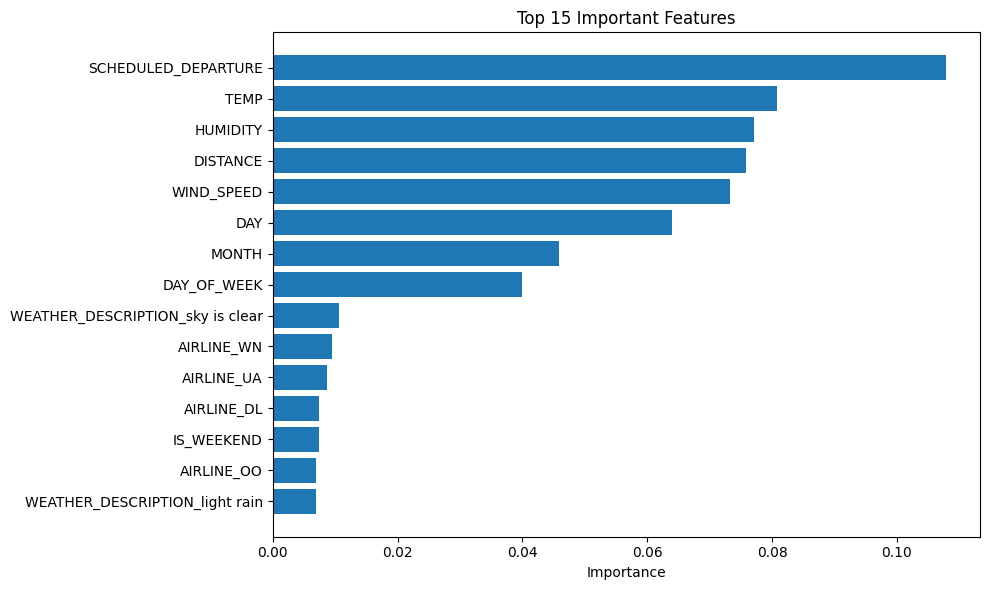

In [ ]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 15 Important Features")

plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

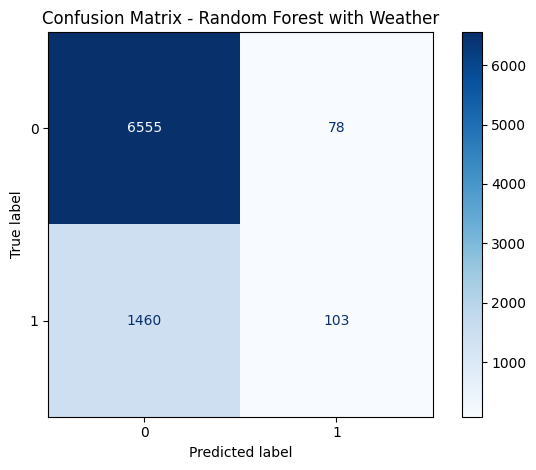

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    yw_test,
    weather_pred,
    cmap="Blues"
)

plt.title("Confusion Matrix - Random Forest with Weather")

plt.tight_layout()

plt.show()

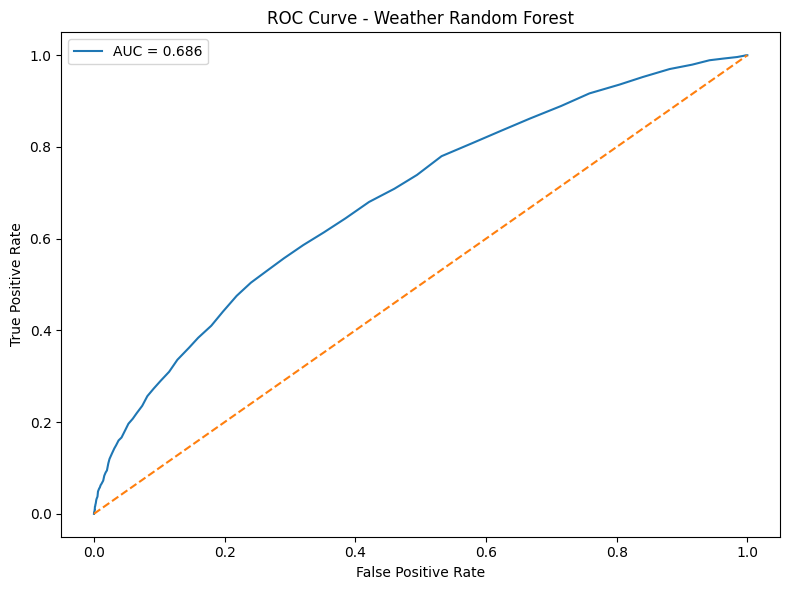

In [ ]:
from sklearn.metrics import roc_curve, auc

weather_probs = weather_rf_model.predict_proba(Xw_test)[:, 1]

fpr, tpr, thresholds = roc_curve(yw_test, weather_probs)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Weather Random Forest")

plt.legend()

plt.tight_layout()

plt.show()

In [ ]:
feature_importance.to_csv(
    base_path + "feature_importance.csv",
    index=False
)

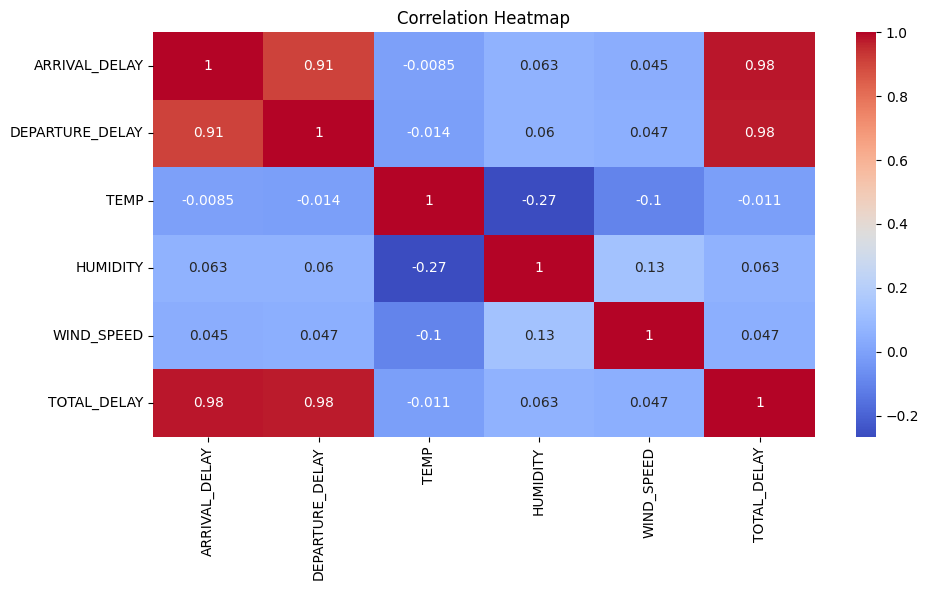

In [ ]:
import seaborn as sns

numeric_subset = weather_merged[
    [
        "ARRIVAL_DELAY",
        "DEPARTURE_DELAY",
        "TEMP",
        "HUMIDITY",
        "WIND_SPEED",
        "TOTAL_DELAY"
    ]
]

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_subset.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()

<Figure size 1000x500 with 0 Axes>

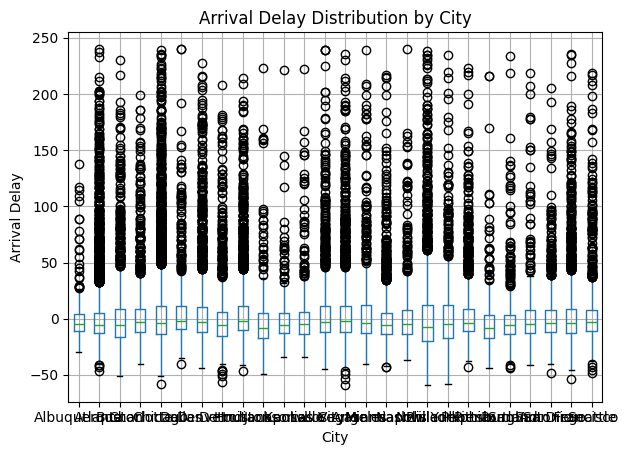

In [ ]:
plt.figure(figsize=(10,5))

weather_merged.boxplot(
    column="ARRIVAL_DELAY",
    by="CITY"
)

plt.title("Arrival Delay Distribution by City")

plt.suptitle("")

plt.xlabel("City")
plt.ylabel("Arrival Delay")

plt.tight_layout()

plt.show()

In [ ]:
weather_merged.to_csv(
    base_path + "final_project_dataset.csv",
    index=False
)

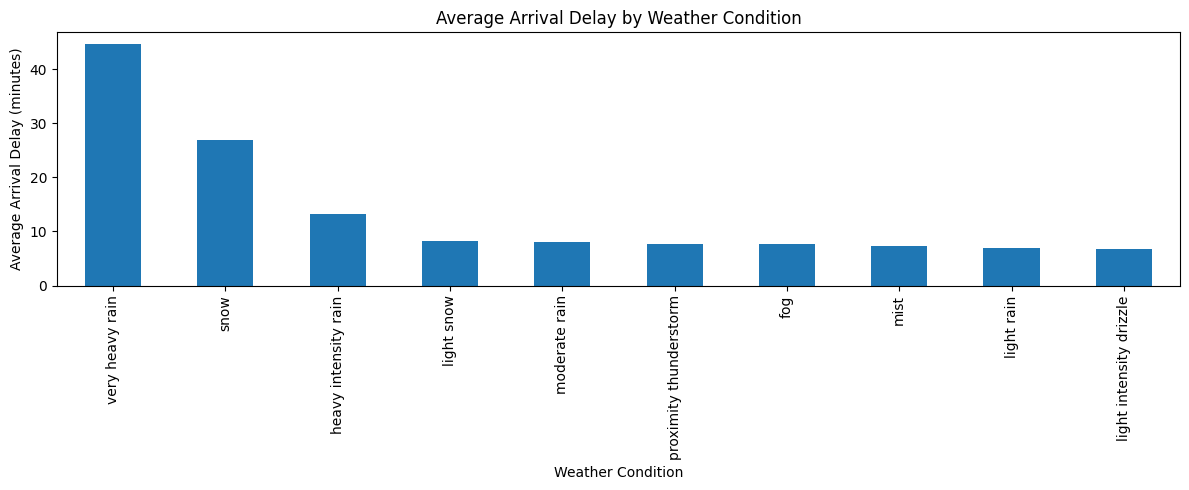

In [ ]:
weather_delay = (
    weather_merged.groupby("WEATHER_DESCRIPTION")["ARRIVAL_DELAY"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,5))

weather_delay.plot(kind="bar")

plt.title("Average Arrival Delay by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Average Arrival Delay (minutes)")

plt.tight_layout()
plt.show()

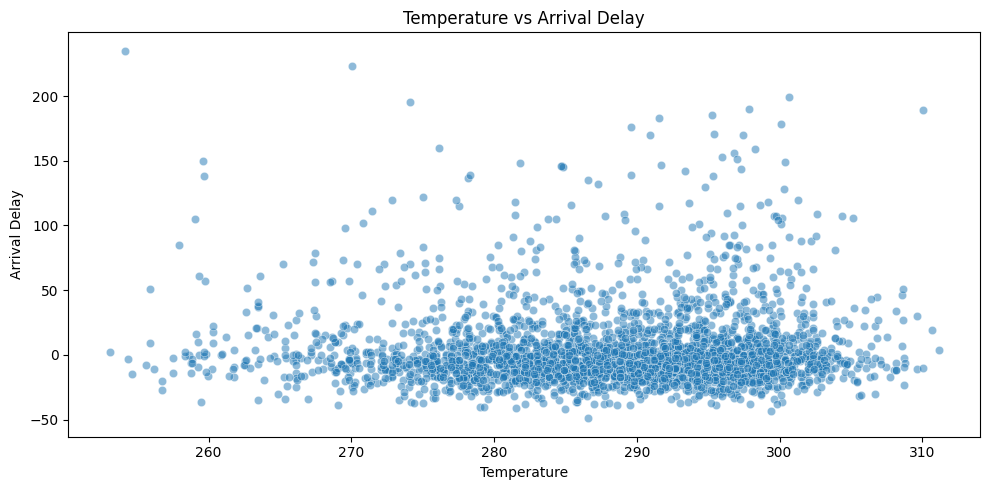

In [ ]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    data=weather_merged.sample(3000),
    x="TEMP",
    y="ARRIVAL_DELAY",
    alpha=0.5
)

plt.title("Temperature vs Arrival Delay")
plt.xlabel("Temperature")
plt.ylabel("Arrival Delay")

plt.tight_layout()
plt.show()

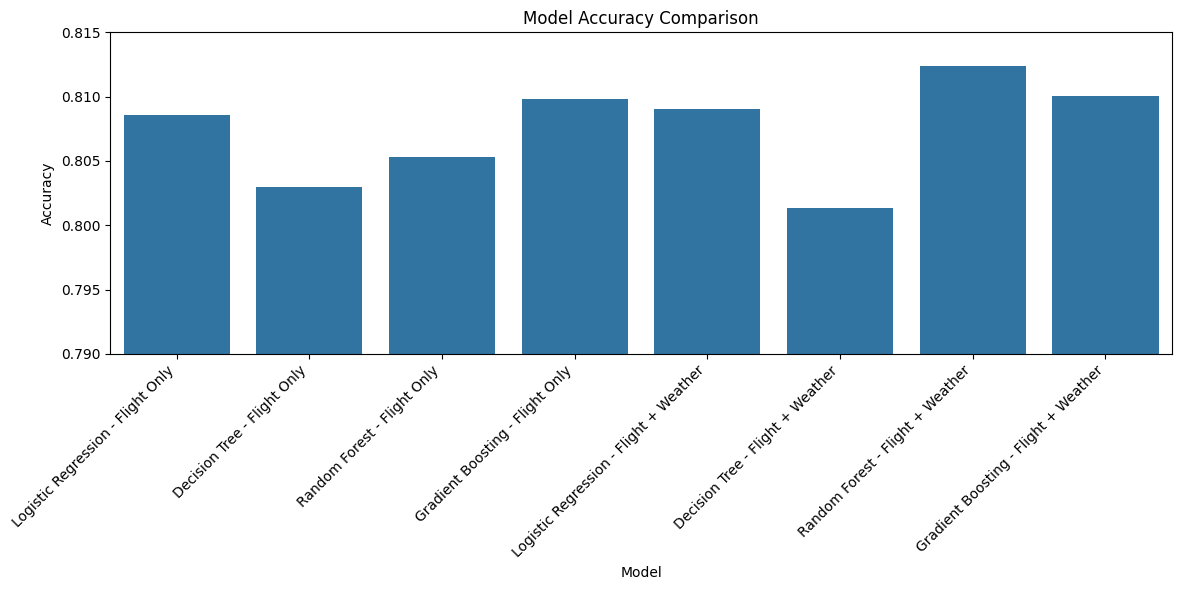

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.ylim(0.79, 0.815)

plt.xticks(rotation=45, ha="right")

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()